In [ ]:
import numpy as np
import librosa
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tqdm import tqdm
from torchvision.models import resnet50
import warnings
warnings.filterwarnings('ignore')

In [3]:
import sys
import os

# Get project root (parent of notebooks folder)
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(project_root)
print(project_root)

c:\Users\akash\Desktop\firstFolder\ml_project\ecl443\EchoEmotion


In [4]:
def load_ravdess_data(ravdess_path, sr=16000):
    """Load RAVDESS dataset"""
    
    X_mel = []
    y_labels = []
    
    actor_folders = sorted([d for d in os.listdir(ravdess_path) 
                           if d.startswith('Actor')])
    
    print(f"Loading from {len(actor_folders)} actors...")
    
    for actor_folder in actor_folders:
        actor_path = os.path.join(ravdess_path, actor_folder)
        
        for filename in os.listdir(actor_path):
            if filename.endswith('.wav'):
                try:
                    filepath = os.path.join(actor_path, filename)
                    y, sr = librosa.load(filepath, sr=sr)
                    
                    # Extract mel-spectrogram
                    mel_spec = librosa.feature.melspectrogram(
                        y=y, sr=sr, n_mels=128, n_fft=2048, hop_length=512
                    )
                    
                    log_mel = librosa.power_to_db(mel_spec, ref=np.max)
                    log_mel = (log_mel - log_mel.min()) / (log_mel.max() - log_mel.min() + 1e-10)
                    
                    X_mel.append(log_mel)
                    
                    emotion_id = filename.split('-')[2]
                    y_labels.append(int(emotion_id) - 1)  # 0-7
                    
                except Exception as e:
                    print(f"Error: {e}")
    
    print(f"✓ Loaded {len(X_mel)} samples")
    
    # Pad to consistent size
    max_len = max([spec.shape[1] for spec in X_mel])
    
    X_mel_padded = []
    for spec in X_mel:
        if spec.shape[1] < max_len:
            spec_padded = np.pad(spec, ((0, 0), (0, max_len - spec.shape[1])), mode='constant')
        else:
            spec_padded = spec[:, :max_len]
        X_mel_padded.append(spec_padded)
    
    X = np.array(X_mel_padded)
    y = np.array(y_labels)
    
    print(f"  Shape: {X.shape}")
    
    return X, y
 

In [5]:
# @title Default title text
class RAVDESSDataset(Dataset):
    """PyTorch dataset for RAVDESS"""
    
    def __init__(self, X, y, augment=False):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
        self.augment = augment
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        spec = self.X[idx]
        
        # Data augmentation
        if self.augment:
            if np.random.rand() > 0.5:
                noise = torch.randn_like(spec) * 0.01
                spec = spec + noise
            
            if np.random.rand() > 0.5:
                shift = np.random.randint(-10, 10)
                spec = torch.roll(spec, shift, dims=1)
        
        # Convert to 3-channel for ResNet (expects RGB)
        spec = torch.stack([spec, spec, spec], dim=0)  # (3, 128, width)
        
        return spec, self.y[idx]

In [7]:
RAVDESS_PATH = os.path.join(project_root, "data", "ravdess")

# Load data
print("\n[1] Loading data...")
X, y = load_ravdess_data(RAVDESS_PATH)

# Split
print("\n[2] Splitting data...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)


[1] Loading data...
Loading from 24 actors...
✓ Loaded 1440 samples
  Shape: (1440, 128, 165)

[2] Splitting data...


In [14]:
# Set device (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [ ]:
class TransferLearningModel(nn.Module):
    """
    ResNet50 pre-trained on ImageNet, fine-tuned for emotion recognition
    """
    
    def __init__(self, num_classes=8):
        super().__init__()
        
        # Load pre-trained ResNet50
        self.resnet = resnet50(pretrained=True)
        
        # Freeze early layers (they learned general features)
        for param in list(self.resnet.parameters())[:-30]:
            param.requires_grad = False
        
        # Replace final layer
        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        return self.resnet(x)

In [9]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch"""
    
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for specs, labels in tqdm(train_loader, desc='Train'):
        specs, labels = specs.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(specs)
        loss = criterion(outputs, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Track
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    
    return total_loss / len(train_loader), correct / total

In [10]:
def validate(model, val_loader, criterion, device):
    """Validate"""
    
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for specs, labels in val_loader:
            specs, labels = specs.to(device), labels.to(device)
            
            outputs = model(specs)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    
    return total_loss / len(val_loader), correct / total
 
 
def train_model(X_train, y_train, X_val, y_val, X_test, y_test, epochs=50):
    """Train transfer learning model"""
    
    # Create datasets
    train_dataset = RAVDESSDataset(X_train, y_train, augment=True)
    val_dataset = RAVDESSDataset(X_val, y_val, augment=False)
    test_dataset = RAVDESSDataset(X_test, y_test, augment=False)
    
    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32)
    test_loader = DataLoader(test_dataset, batch_size=32)
    
    # Model
    model = TransferLearningModel(num_classes=8).to(device)
    
    # Loss & optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, 
                                                      patience=5, min_lr=1e-6)
    
    # Training loop
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    
    best_val_acc = 0
    patience = 10
    patience_counter = 0
    
    print("\nTraining started...")
    
    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%")
        print(f"  Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc*100:.2f}%")
        
        # Learning rate scheduling
        scheduler.step(val_loss)
        
        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\nEarly stopping at epoch {epoch+1}")
                break
    
    # Load best model and evaluate
    model.load_state_dict(torch.load('best_model.pth'))
    
    print("\n" + "="*70)
    print("FINAL RESULTS (Transfer Learning)")
    print("="*70)
    
    # Test accuracy
    model.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        for specs, labels in test_loader:
            specs, labels = specs.to(device), labels.to(device)
            outputs = model(specs)
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
        
        test_acc = correct / total
    
    print(f"Test Accuracy: {test_acc*100:.2f}%")
    print(f"✓ Improvement from 49% → {test_acc*100:.1f}% expected!")
    
    return model, {'train_losses': train_losses, 'val_losses': val_losses,
                   'train_accs': train_accs, 'val_accs': val_accs}
                   

In [11]:
# VISUALIZATION
# ============================================================================
 
def plot_results(history):
    """Plot training curves"""
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].plot(history['train_accs'], label='Train')
    axes[0].plot(history['val_accs'], label='Val')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_title('Accuracy')
    axes[0].legend()
    axes[0].grid()
    
    axes[1].plot(history['train_losses'], label='Train')
    axes[1].plot(history['val_losses'], label='Val')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('Loss')
    axes[1].legend()
    axes[1].grid()
    
    plt.tight_layout()
    plt.savefig('training_results_pytorch.png', dpi=150)
    plt.show()


[3] Training...


Using cache found in C:\Users\akash/.cache\torch\hub\pytorch_vision_v0.10.0



Training started...


Train: 100%|██████████| 33/33 [01:13<00:00,  2.22s/it]



Epoch 1/50
  Train Loss: 1.8925, Train Acc: 25.87%
  Val Loss:   2.7414, Val Acc:   26.09%


...


Epoch 35/50
  Train Loss: 0.1111, Train Acc: 96.73%
  Val Loss:   1.4402, Val Acc:   64.13%


Train: 100%|██████████| 33/33 [01:12<00:00,  2.19s/it]



Epoch 36/50
  Train Loss: 0.1290, Train Acc: 96.15%
  Val Loss:   1.4583, Val Acc:   65.22%


Train: 100%|██████████| 33/33 [01:12<00:00,  2.18s/it]



Epoch 37/50
  Train Loss: 0.1030, Train Acc: 96.54%
  Val Loss:   1.3948, Val Acc:   63.59%

Early stopping at epoch 37

FINAL RESULTS (Transfer Learning)
Test Accuracy: 58.80%
✓ Improvement from 49% → 58.8% expected!

[4] Plotting...


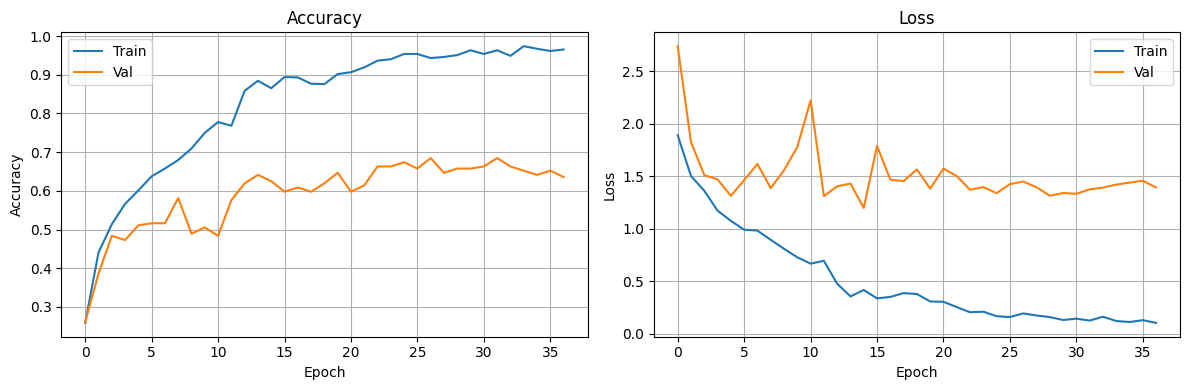


✓ Done!


In [15]:
# Train
print("\n[3] Training...")
model, history = train_model(X_train, y_train, X_val, y_val, X_test, y_test, epochs=50)

# Plot
print("\n[4] Plotting...")
plot_results(history)

print("\n✓ Done!")